In [1]:
# Berlin Rental Market - Exploratory Data Analysis
# By Anurag Panwar
# Dataset: Berlin Airbnb Weekday Listings

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Anurag panwar\Desktop\berlin_weekdays.csv")

print(df.shape)
print(df.head())

(1284, 20)
   Unnamed: 0     realSum     room_type  room_shared  room_private  \
0           0  185.799757  Private room        False          True   
1           1  194.914462  Private room        False          True   
2           2  176.217631  Private room        False          True   
3           3  207.768533  Private room        False          True   
4           4  150.743199  Private room        False          True   

   person_capacity  host_is_superhost  multi  biz  cleanliness_rating  \
0              2.0               True      0    0                10.0   
1              5.0              False      0    1                 9.0   
2              2.0              False      0    0                 9.0   
3              3.0               True      0    0                10.0   
4              2.0              False      0    0                10.0   

   guest_satisfaction_overall  bedrooms      dist  metro_dist  attr_index  \
0                        98.0         1  3.582211   

In [4]:
print(df.dtypes)

Unnamed: 0                      int64
realSum                       float64
room_type                         str
room_shared                      bool
room_private                     bool
person_capacity               float64
host_is_superhost                bool
multi                           int64
biz                             int64
cleanliness_rating            float64
guest_satisfaction_overall    float64
bedrooms                        int64
dist                          float64
metro_dist                    float64
attr_index                    float64
attr_index_norm               float64
rest_index                    float64
rest_index_norm               float64
lng                           float64
lat                           float64
dtype: object


In [5]:
print(df.isnull().sum())

Unnamed: 0                    0
realSum                       0
room_type                     0
room_shared                   0
room_private                  0
person_capacity               0
host_is_superhost             0
multi                         0
biz                           0
cleanliness_rating            0
guest_satisfaction_overall    0
bedrooms                      0
dist                          0
metro_dist                    0
attr_index                    0
attr_index_norm               0
rest_index                    0
rest_index_norm               0
lng                           0
lat                           0
dtype: int64


In [6]:
print(df["room_type"].value_counts())

room_type
Private room       775
Entire home/apt    474
Shared room         35
Name: count, dtype: int64


In [7]:
price_by_room = df.groupby("room_type")["realSum"].mean()
print(price_by_room)

room_type
Entire home/apt    351.994960
Private room       176.219742
Shared room        143.631726
Name: realSum, dtype: float64


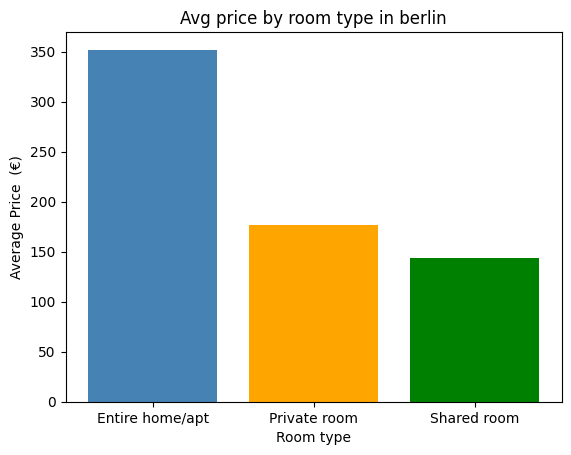

In [9]:
plt.bar(price_by_room.index, price_by_room.values, color=["steelblue", "orange", "green"])
plt.title("Avg price by room type in berlin")
plt.xlabel("Room type")
plt.ylabel("Average Price  (€)")
plt.show()

In [10]:
price_by_superhost = df.groupby("host_is_superhost")["realSum"].mean()
print(price_by_superhost)

host_is_superhost
False    237.410552
True     247.959886
Name: realSum, dtype: float64


In [11]:
print(df["dist"].describe())

count    1284.000000
mean        5.264371
std         3.681616
min         0.180926
25%         2.857516
50%         4.300548
75%         6.663819
max        22.617451
Name: dist, dtype: float64


In [12]:
df["dist_group"] = pd.cut(df["dist"],
                          bins=[0, 2, 5, 10, 25],
                          labels=["0-2km", "2-5km", "5-10km", "10-25km"])
price_by_dist = df.groupby("dist_group")["realSum"].mean()
print(price_by_dist)

dist_group
0-2km      321.553211
2-5km      249.155340
5-10km     207.131602
10-25km    193.832872
Name: realSum, dtype: float64


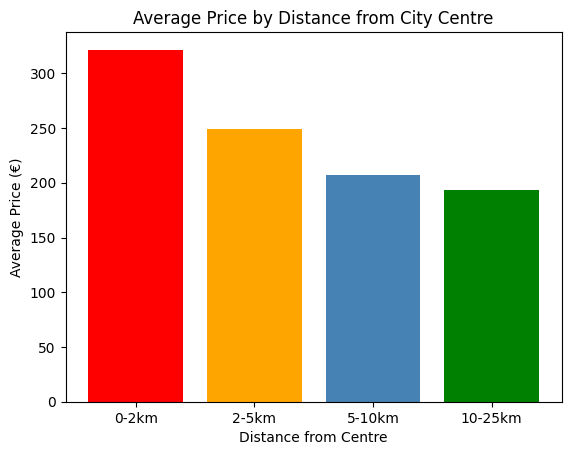

In [13]:
plt.bar(price_by_dist.index, price_by_dist.values, color=["red", "orange", "steelblue", "green"])
plt.title("Average Price by Distance from City Centre")
plt.xlabel("Distance from Centre")
plt.ylabel("Average Price (€)")
plt.show()

In [14]:
price_by_cleanliness = df.groupby("cleanliness_rating")["realSum"].mean()
print(price_by_cleanliness)

cleanliness_rating
4.0     271.649372
5.0     115.920352
6.0     210.689913
7.0     155.339503
8.0     233.240115
9.0     234.747353
10.0    246.959518
Name: realSum, dtype: float64


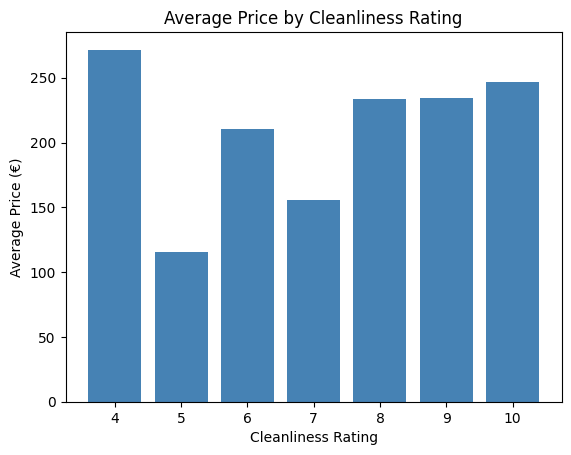

In [15]:
plt.bar(price_by_cleanliness.index, price_by_cleanliness.values, color="steelblue")
plt.title("Average Price by Cleanliness Rating")
plt.xlabel("Cleanliness Rating")
plt.ylabel("Average Price (€)")
plt.show()

In [16]:
print(df["guest_satisfaction_overall"].describe())

count    1284.000000
mean       94.299065
std         6.912388
min        20.000000
25%        92.000000
50%        96.000000
75%        99.000000
max       100.000000
Name: guest_satisfaction_overall, dtype: float64


In [17]:
df["satisfaction_group"] = pd.cut(df["guest_satisfaction_overall"],
                                   bins=[0, 80, 90, 95, 100],
                                   labels=["Below 80", "80-90", "90-95", "95-100"])

price_by_satisfaction = df.groupby("satisfaction_group")["realSum"].mean()
print(price_by_satisfaction)

satisfaction_group
Below 80    280.471012
80-90       228.516173
90-95       223.663865
95-100      247.131993
Name: realSum, dtype: float64


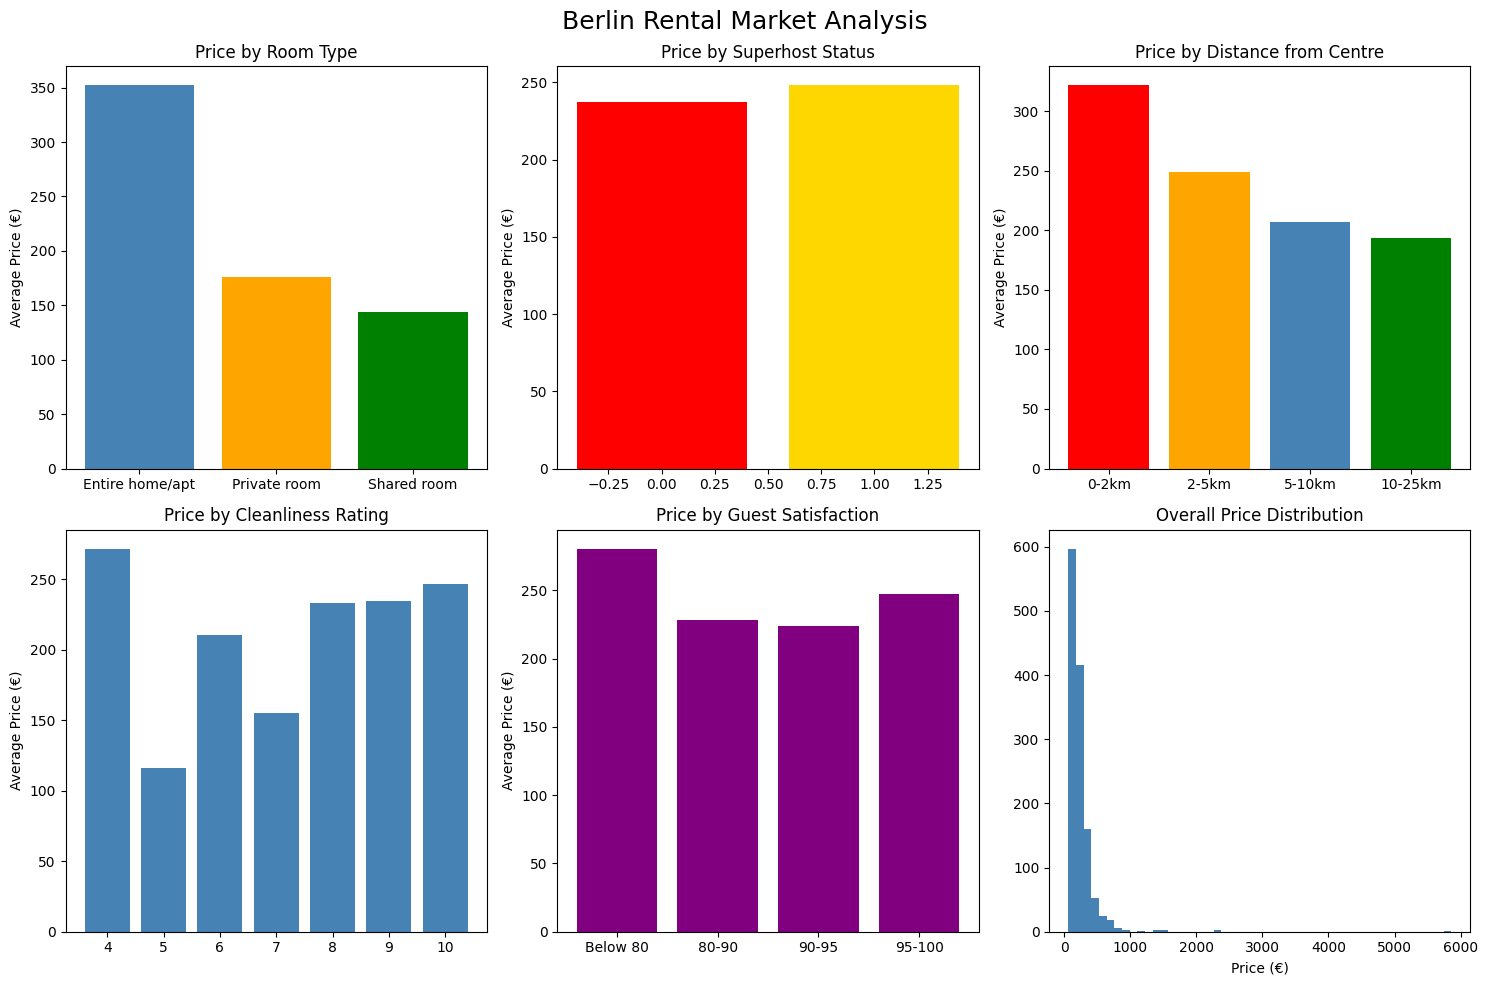

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Berlin Rental Market Analysis", fontsize=18)

# Chart 1 - Price by Room Type
axes[0,0].bar(price_by_room.index, price_by_room.values, color=["steelblue", "orange", "green"])
axes[0,0].set_title("Price by Room Type")
axes[0,0].set_ylabel("Average Price (€)")

# Chart 2 - Price by Superhost
axes[0,1].bar(price_by_superhost.index, price_by_superhost.values, color=["red", "gold"])
axes[0,1].set_title("Price by Superhost Status")
axes[0,1].set_ylabel("Average Price (€)")

# Chart 3 - Price by Distance
axes[0,2].bar(price_by_dist.index, price_by_dist.values, color=["red", "orange", "steelblue", "green"])
axes[0,2].set_title("Price by Distance from Centre")
axes[0,2].set_ylabel("Average Price (€)")

# Chart 4 - Price by Cleanliness
axes[1,0].bar(price_by_cleanliness.index, price_by_cleanliness.values, color="steelblue")
axes[1,0].set_title("Price by Cleanliness Rating")
axes[1,0].set_ylabel("Average Price (€)")

# Chart 5 - Price by Satisfaction
axes[1,1].bar(price_by_satisfaction.index, price_by_satisfaction.values, color="purple")
axes[1,1].set_title("Price by Guest Satisfaction")
axes[1,1].set_ylabel("Average Price (€)")

# Chart 6 - Price Distribution
axes[1,2].hist(df["realSum"], bins=50, color="steelblue")
axes[1,2].set_title("Overall Price Distribution")
axes[1,2].set_xlabel("Price (€)")

plt.tight_layout()
plt.show()

In [22]:
print("""
BERLIN RENTAL MARKET - KEY FINDINGS
=====================================

1. ROOM TYPE affects price the most:
   - Entire home/apt: €352/night
   - Private room: €176/night  
   - Shared room: €144/night

2. LOCATION is the second biggest factor:
   - Within 2km of centre: €322/night
   - 10km+ from centre: €194/night

3. SUPERHOST status has minimal impact:
   - Superhosts charge only €11 more on average

4. CLEANLINESS RATING has no clear price impact
   - Price driven by location and room type instead

5. GUEST SATISFACTION has no direct price impact
   - Low rated listings can still be expensive
""")



BERLIN RENTAL MARKET - KEY FINDINGS

1. ROOM TYPE affects price the most:
   - Entire home/apt: €352/night
   - Private room: €176/night  
   - Shared room: €144/night

2. LOCATION is the second biggest factor:
   - Within 2km of centre: €322/night
   - 10km+ from centre: €194/night

3. SUPERHOST status has minimal impact:
   - Superhosts charge only €11 more on average

4. CLEANLINESS RATING has no clear price impact
   - Price driven by location and room type instead

5. GUEST SATISFACTION has no direct price impact
   - Low rated listings can still be expensive

